# Log File Analysis with Hadoop + PySpark
### Counting 404 Errors and Visualizing Failure Patterns by Time of Day

**Final Project / Exam Presentation**

**Pipeline:** Server Logs → Hadoop HDFS (storage) → PySpark (distributed processing) → Pandas/Matplotlib (visualization)

---

**What this notebook covers:**
1. Why Hadoop + Spark for log analysis (Big Data motivation)
2. Setting up a Spark Session (with notes on connecting to real HDFS)
3. Ingesting massive log files (with a realistic synthetic dataset generator)
4. Robust log parsing with regex + a defined schema
5. Data cleaning and caching for performance
6. Counting "404 Error" occurrences
7. Aggregating failures by hour of day (and day of week)
8. Visualizations: bar chart, heatmap, time series, top failing endpoints
9. Key insights & conclusion (for your presentation talking points)


## 1. Why Hadoop + PySpark?

Server logs from large web applications can reach **gigabytes to terabytes per day**. A single machine using plain Python/Pandas cannot efficiently load or process files at that scale because:

- The entire file must fit in memory (Pandas loads everything into RAM)
- Processing is single-threaded / single-machine

**Hadoop (HDFS)** solves the *storage* problem: it splits massive log files into blocks (default 128MB) distributed across a cluster of machines, replicated for fault tolerance.

**PySpark** solves the *processing* problem: it reads data directly from HDFS and processes it in parallel across the cluster using **distributed DataFrames**, only pulling small aggregated results back to the driver (this notebook) for visualization.

**Typical real-world flow:**
```
Web Servers (nginx/apache) --> Log Shipper (Flume/Filebeat) --> HDFS (raw storage)
                                                                     |
                                                                     v
                                                        PySpark (parse, clean, aggregate)
                                                                     |
                                                                     v
                                                    Parquet output / Dashboard (Pandas, BI tool)
```

In this notebook we run Spark in **local mode** (`local[*]`) so it works in Jupyter without a real cluster, but every line of PySpark code shown is identical to what you'd run against real HDFS — you would simply change the file path from `server.log` to `hdfs://namenode:9000/logs/server.log`.


## 2. Environment Setup

Install PySpark and visualization libraries, then start a Spark Session.

In [1]:
# Run once
!pip install pyspark matplotlib seaborn pandas faker --quiet

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, TimestampType

spark = SparkSession.builder \
    .appName("LogFileAnalysis-404Errors") \
    .master("local[*]") \
    .config("spark.sql.session.timeZone", "UTC") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")   # hide noisy INFO logs
print("Spark version:", spark.version)
spark

Spark version: 4.2.0


> **Connecting to real HDFS instead:** if you have a Hadoop cluster running, you only need to change the read path later to something like:
> ```python
> raw_df = spark.read.text("hdfs://localhost:9000/user/logs/server.log")
> ```
> Everything else in this notebook stays exactly the same — that's the power of Spark's unified API.


## 3. Ingesting the Log File

For the presentation/demo we generate a **realistic synthetic Apache/NGINX-style access log** (Common Log Format) with ~200,000 lines, including intentional traffic spikes and error-prone hours so the "time of day" pattern is meaningful to show.

> If you have a real log file, skip this cell and just point `spark.read.text()` at your file / HDFS path in Step 4.


In [3]:
import random
from datetime import datetime, timedelta

random.seed(42)

N_LINES = 200_000
START_DATE = datetime(2026, 9, 1)
DAYS = 7

paths = ["/index.html", "/home", "/about", "/login", "/api/users", "/api/orders",
         "/checkout", "/product/123", "/product/456", "/old-promo-page",
         "/deprecated-api/v1", "/images/logo.png", "/favicon.ico", "/admin/login"]

# Paths that realistically cause more 404s (deprecated / typo-prone / removed)
error_prone_paths = ["/old-promo-page", "/deprecated-api/v1", "/admin/login", "/product/999"]

methods = ["GET", "GET", "GET", "POST", "PUT", "DELETE"]

# Hours where traffic (and thus errors) spike -> peak business hours + a late-night bot-scan spike
peak_hours = [9, 10, 11, 14, 15, 20, 21]
bot_scan_hours = [2, 3]  # simulate automated scanners hammering broken endpoints at night

def random_hour():
    r = random.random()
    if r < 0.55:
        return random.choice(peak_hours)
    elif r < 0.70:
        return random.choice(bot_scan_hours)
    else:
        return random.randint(0, 23)

def random_status(path, hour):
    # bot scan hours hitting deprecated endpoints -> very high 404 rate
    if hour in bot_scan_hours and path in error_prone_paths:
        return random.choices([404, 500, 403], weights=[85, 10, 5])[0]
    if path in error_prone_paths:
        return random.choices([200, 404, 301], weights=[30, 60, 10])[0]
    return random.choices([200, 301, 404, 500, 403], weights=[80, 5, 10, 3, 2])[0]

ips = [f"10.0.{random.randint(0,50)}.{random.randint(1,254)}" for _ in range(500)]

lines = []
for _ in range(N_LINES):
    day_offset = random.randint(0, DAYS - 1)
    hour = random_hour()
    minute = random.randint(0, 59)
    second = random.randint(0, 59)
    ts = START_DATE + timedelta(days=day_offset, hours=hour, minutes=minute, seconds=second)

    ip = random.choice(ips)
    method = random.choice(methods)
    path = random.choice(paths)
    status = random_status(path, hour)
    size = random.randint(150, 5000)

    line = f'{ip} - - [{ts.strftime("%d/%b/%Y:%H:%M:%S")} +0000] "{method} {path} HTTP/1.1" {status} {size}'
    lines.append(line)

with open("server.log", "w") as f:
    f.write("\n".join(lines))

print(f"Generated server.log with {N_LINES:,} lines")
print("Sample lines:")
for l in lines[:3]:
    print(" ", l)

Generated server.log with 200,000 lines
Sample lines:
  10.0.34.176 - - [04/Sep/2026:03:27:23 +0000] "POST /images/logo.png HTTP/1.1" 200 1592
  10.0.44.40 - - [06/Sep/2026:20:17:39 +0000] "PUT /favicon.ico HTTP/1.1" 200 3718
  10.0.30.243 - - [07/Sep/2026:08:20:54 +0000] "GET /api/users HTTP/1.1" 404 2147


**In a real Hadoop deployment**, you would upload this file to HDFS first, e.g. from the terminal:
```bash
hdfs dfs -mkdir -p /user/logs
hdfs dfs -put server.log /user/logs/server.log
```
Then Spark reads directly from HDFS in the next step.

In [4]:
# INGEST: read the raw text file into Spark (this is the "massive file" ingestion step)
# Swap the path below for "hdfs://namenode:9000/user/logs/server.log" against a real cluster.
raw_df = spark.read.text("server.log")

print("Total raw lines ingested:", raw_df.count())
raw_df.show(5, truncate=False)

Total raw lines ingested: 200000
+--------------------------------------------------------------------------------------+
|value                                                                                 |
+--------------------------------------------------------------------------------------+
|10.0.34.176 - - [04/Sep/2026:03:27:23 +0000] "POST /images/logo.png HTTP/1.1" 200 1592|
|10.0.44.40 - - [06/Sep/2026:20:17:39 +0000] "PUT /favicon.ico HTTP/1.1" 200 3718      |
|10.0.30.243 - - [07/Sep/2026:08:20:54 +0000] "GET /api/users HTTP/1.1" 404 2147       |
|10.0.4.114 - - [07/Sep/2026:15:42:24 +0000] "GET /product/123 HTTP/1.1" 404 1639      |
|10.0.4.182 - - [04/Sep/2026:21:16:21 +0000] "PUT /images/logo.png HTTP/1.1" 404 4703  |
+--------------------------------------------------------------------------------------+
only showing top 5 rows


## 4. Parsing Log Lines with Regex

Log format (Common Log Format):
```
IP - - [DD/Mon/YYYY:HH:MM:SS +ZZZZ] "METHOD PATH HTTP/1.1" STATUS SIZE
```

We extract each field with a regex and cast into proper types so Spark can filter/aggregate efficiently.

In [5]:
LOG_PATTERN = r'^(\S+) \S+ \S+ \[(\d{2}/\w{3}/\d{4}:\d{2}:\d{2}:\d{2}) [^\]]+\] "(\S+) (\S+) [^"]*" (\d{3}) (\d+)'

parsed_df = raw_df.select(
    F.regexp_extract('value', LOG_PATTERN, 1).alias('ip'),
    F.regexp_extract('value', LOG_PATTERN, 2).alias('timestamp_str'),
    F.regexp_extract('value', LOG_PATTERN, 3).alias('method'),
    F.regexp_extract('value', LOG_PATTERN, 4).alias('path'),
    F.regexp_extract('value', LOG_PATTERN, 5).alias('status'),
    F.regexp_extract('value', LOG_PATTERN, 6).cast(IntegerType()).alias('size'),
).withColumn(
    'timestamp', F.to_timestamp('timestamp_str', 'dd/MMM/yyyy:HH:mm:ss')
).withColumn(
    'status', F.col('status').cast(IntegerType())
).withColumn(
    'hour', F.hour('timestamp')
).withColumn(
    'day_of_week', F.date_format('timestamp', 'EEEE')
)

parsed_df.printSchema()
parsed_df.show(5, truncate=False)

root
 |-- ip: string (nullable = true)
 |-- timestamp_str: string (nullable = true)
 |-- method: string (nullable = true)
 |-- path: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- size: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: string (nullable = true)

+-----------+--------------------+------+----------------+------+----+-------------------+----+-----------+
|ip         |timestamp_str       |method|path            |status|size|timestamp          |hour|day_of_week|
+-----------+--------------------+------+----------------+------+----+-------------------+----+-----------+
|10.0.34.176|04/Sep/2026:03:27:23|POST  |/images/logo.png|200   |1592|2026-09-04 03:27:23|3   |Friday     |
|10.0.44.40 |06/Sep/2026:20:17:39|PUT   |/favicon.ico    |200   |3718|2026-09-06 20:17:39|20  |Sunday     |
|10.0.30.243|07/Sep/2026:08:20:54|GET   |/api/users      |404   |2147|2026-09-07 08:20:54|8   |Monday

### Data Cleaning
Drop any lines that failed to match the regex (malformed / truncated log lines are common in real-world massive files) and **cache** the cleaned DataFrame in memory since we will query it repeatedly.

In [6]:
clean_df = parsed_df.filter(
    (F.col('timestamp').isNotNull()) & (F.col('status').isNotNull())
)

malformed_count = raw_df.count() - clean_df.count()
print(f"Malformed / unparseable lines dropped: {malformed_count:,}")

clean_df.cache()
print(f"Clean records ready for analysis: {clean_df.count():,}")

Malformed / unparseable lines dropped: 0
Clean records ready for analysis: 200,000


## 5. Counting "404 Error" Occurrences

In [7]:
total_requests = clean_df.count()
error_404_df = clean_df.filter(F.col('status') == 404)
total_404 = error_404_df.count()
error_rate = (total_404 / total_requests) * 100

print(f"Total requests analyzed : {total_requests:,}")
print(f"Total 404 errors        : {total_404:,}")
print(f"404 error rate          : {error_rate:.2f}%")

# Breakdown of ALL status codes, for context in your presentation
status_breakdown = clean_df.groupBy('status').agg(F.count('*').alias('count')) \
    .orderBy(F.desc('count'))
status_breakdown.show()

# Export to CSV
status_breakdown_pdf = status_breakdown.toPandas()
status_breakdown_pdf.to_csv("status_code_breakdown.csv", index=False)
print("Saved: status_code_breakdown.csv")

# Save headline numbers to a small text file too -- used later to build the written report
with open("summary_stats.txt", "w") as f:
    f.write(f"total_requests={total_requests}\n")
    f.write(f"total_404={total_404}\n")
    f.write(f"error_rate={error_rate:.2f}\n")

Total requests analyzed : 200,000
Total 404 errors        : 43,153
404 error rate          : 21.58%
+------+------+
|status| count|
+------+------+
|   200|136415|
|   404| 43153|
|   301| 11417|
|   500|  5540|
|   403|  3475|
+------+------+

Saved: status_code_breakdown.csv


## 6. Aggregating 404 Errors by Hour of Day

This answers the core question: **"What time of day do most failures happen?"**

In [8]:
hourly_404 = error_404_df.groupBy('hour') \
    .agg(F.count('*').alias('error_count')) \
    .orderBy('hour')

hourly_404.show(24)

# Pull the small aggregated result to the driver as Pandas for plotting
hourly_pdf = hourly_404.toPandas()
# ensure all 24 hours are present even if some had zero errors
hourly_pdf = hourly_pdf.set_index('hour').reindex(range(24), fill_value=0).reset_index()
peak_hour = hourly_pdf.loc[hourly_pdf['error_count'].idxmax(), 'hour']
print(f"\nPeak failure hour: {int(peak_hour)}:00 - {int(peak_hour)+1}:00")

# Export to CSV -- this is one of the deliverables for the report
hourly_pdf.to_csv("hourly_404_errors.csv", index=False)
print("Saved: hourly_404_errors.csv")

+----+-----------+
|hour|error_count|
+----+-----------+
|   0|        528|
|   1|        463|
|   2|       4434|
|   3|       4655|
|   4|        555|
|   5|        536|
|   6|        540|
|   7|        506|
|   8|        487|
|   9|       3715|
|  10|       3647|
|  11|       3722|
|  12|        521|
|  13|        514|
|  14|       3839|
|  15|       3854|
|  16|        538|
|  17|        477|
|  18|        494|
|  19|        508|
|  20|       3873|
|  21|       3717|
|  22|        533|
|  23|        497|
+----+-----------+


Peak failure hour: 3:00 - 4:00
Saved: hourly_404_errors.csv


## 7. Visualizations

### 7.1 — 404 Errors by Hour of Day (Bar Chart)

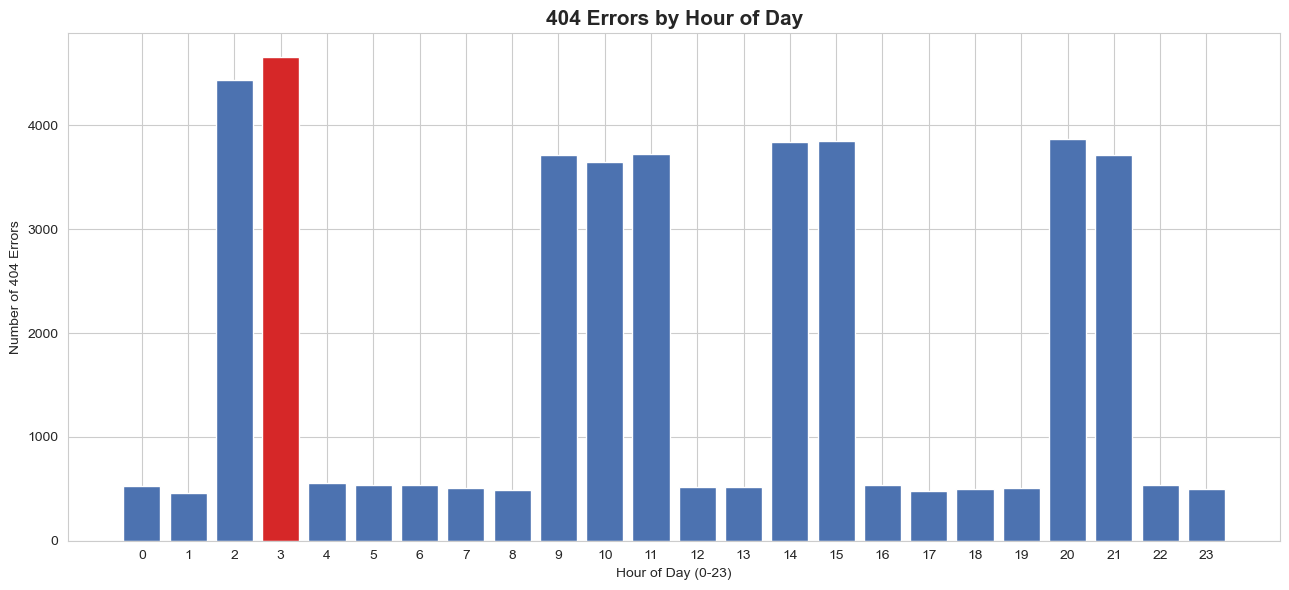

Peak hour highlighted in red: 3:00


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(13, 6))
colors = ['#d62728' if h == peak_hour else '#4c72b0' for h in hourly_pdf['hour']]
bars = plt.bar(hourly_pdf['hour'], hourly_pdf['error_count'], color=colors)

plt.title("404 Errors by Hour of Day", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of 404 Errors")
plt.xticks(range(24))
plt.tight_layout()
plt.savefig("404_errors_by_hour.png", dpi=150)
plt.show()
print(f"Peak hour highlighted in red: {int(peak_hour)}:00")

### 7.2 — Heatmap: 404 Errors by Day of Week × Hour
This reveals *when in the week* problems concentrate (e.g. weekday bot scans at night vs. weekend business-hour spikes).

Saved: heatmap_day_hour_404.csv


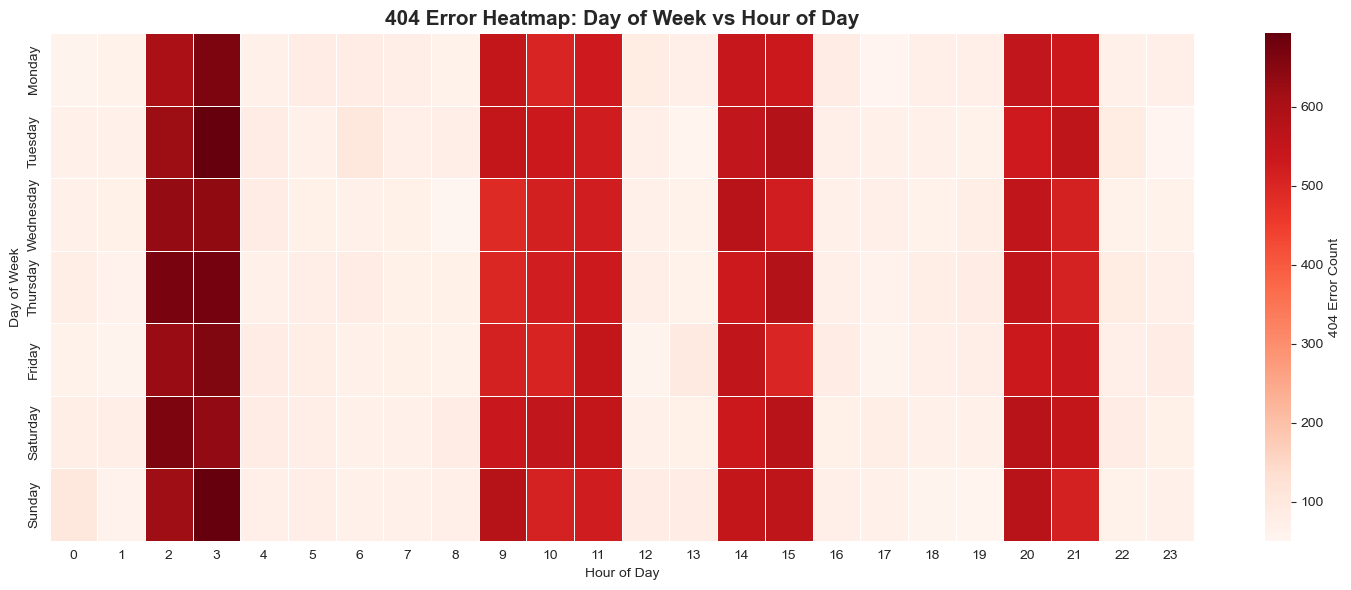

In [10]:
heatmap_df = error_404_df.groupBy('day_of_week', 'hour') \
    .agg(F.count('*').alias('error_count'))

heatmap_pdf = heatmap_df.toPandas()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = heatmap_pdf.pivot_table(index='day_of_week', columns='hour', values='error_count', fill_value=0)
pivot = pivot.reindex(day_order)

# Export to CSV
pivot.to_csv("heatmap_day_hour_404.csv")
print("Saved: heatmap_day_hour_404.csv")

plt.figure(figsize=(15, 6))
sns.heatmap(pivot, cmap="Reds", linewidths=0.5, cbar_kws={'label': '404 Error Count'})
plt.title("404 Error Heatmap: Day of Week vs Hour of Day", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig("404_heatmap_day_hour.png", dpi=150)
plt.show()

### 7.3 — Top Endpoints Causing 404 Errors
Useful to identify *which* broken links/deprecated APIs need fixing.

Saved: top_404_paths.csv


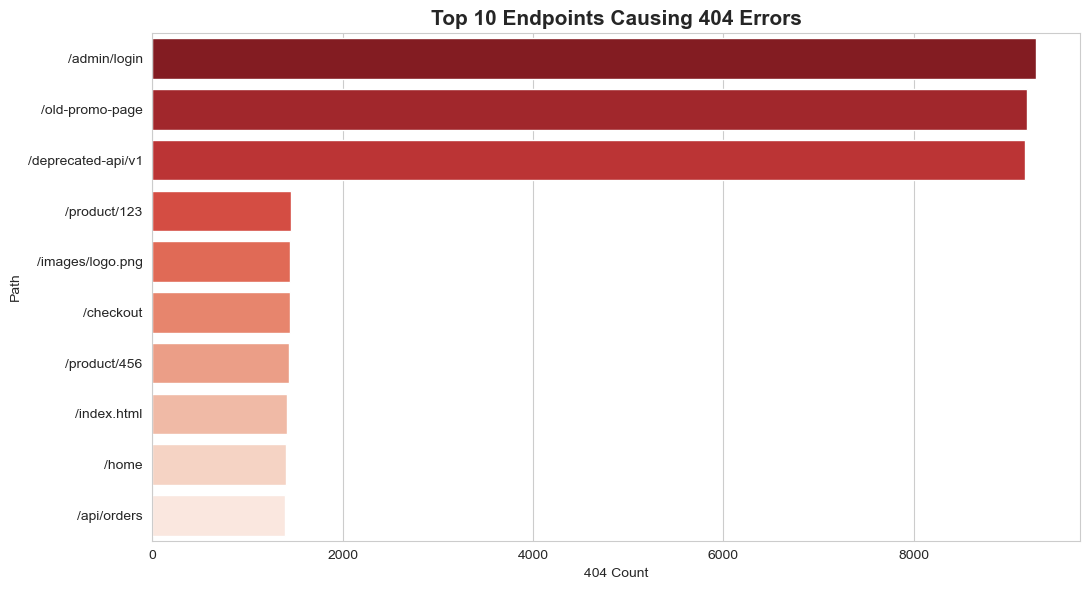

In [11]:
top_paths = error_404_df.groupBy('path') \
    .agg(F.count('*').alias('hits')) \
    .orderBy(F.desc('hits')) \
    .limit(10)

top_paths_pdf = top_paths.toPandas()

# Export to CSV
top_paths_pdf.to_csv("top_404_paths.csv", index=False)
print("Saved: top_404_paths.csv")

plt.figure(figsize=(11, 6))
sns.barplot(data=top_paths_pdf, y='path', x='hits', hue='path', palette='Reds_r', legend=False)
plt.title("Top 10 Endpoints Causing 404 Errors", fontsize=15, fontweight='bold')
plt.xlabel("404 Count")
plt.ylabel("Path")
plt.tight_layout()
plt.savefig("top_404_paths.png", dpi=150)
plt.show()

### 7.4 — Daily Trend of 404 Errors Over Time
Shows whether errors are increasing/decreasing across the week (good for spotting a regression after a deploy).

Saved: daily_404_trend.csv


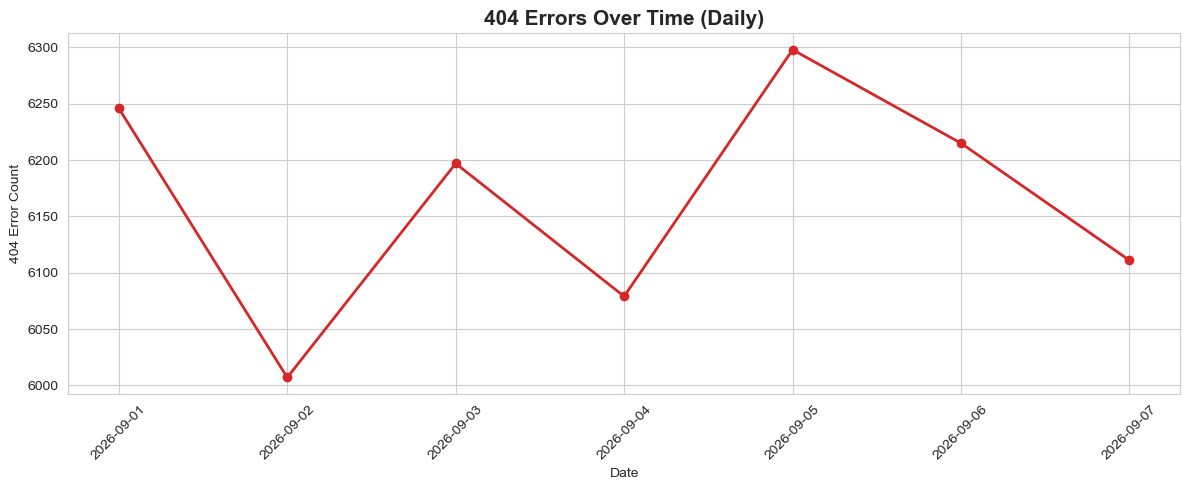

In [12]:
daily_trend = error_404_df.withColumn('date', F.to_date('timestamp')) \
    .groupBy('date') \
    .agg(F.count('*').alias('error_count')) \
    .orderBy('date')

daily_trend_pdf = daily_trend.toPandas()

# Export to CSV
daily_trend_pdf.to_csv("daily_404_trend.csv", index=False)
print("Saved: daily_404_trend.csv")

plt.figure(figsize=(12, 5))
plt.plot(daily_trend_pdf['date'], daily_trend_pdf['error_count'], marker='o', color='#d62728', linewidth=2)
plt.title("404 Errors Over Time (Daily)", fontsize=15, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("404 Error Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("404_daily_trend.png", dpi=150)
plt.show()

## 8. Scaling to Truly Massive Logs (Presentation Talking Points)

For a real multi-GB/TB log dataset on an actual Hadoop cluster, these are the practices to mention:

| Concern | Technique |
|---|---|
| Storage | Store raw logs on **HDFS**, replicated across DataNodes (default replication factor 3) for fault tolerance |
| File size | Prefer fewer large files over millions of tiny files — HDFS handles large block-sized files (128MB+) far more efficiently |
| Parsing cost | Use `regexp_extract` (built-in Spark SQL function) instead of a Python UDF — UDFs break Spark's Catalyst optimizer and run row-by-row in the JVM↔Python bridge, which is much slower |
| Repeated queries | `.cache()` / `.persist()` the cleaned DataFrame once, since we query it many times (count, groupBy hour, groupBy path, groupBy date) |
| Output format | Write aggregated results to **Parquet** (columnar, compressed) instead of CSV for downstream BI tools |
| Partitioning | Partition output by date (`df.write.partitionBy("date").parquet(...)`) so future queries can skip irrelevant partitions |
| Cluster resources | Tune `spark.executor.memory`, `spark.executor.cores`, and number of executors based on cluster size; use `spark.sql.shuffle.partitions` to avoid too-small/too-large shuffle partitions on `groupBy` |

Example of writing results back out for a dashboard:
```python
hourly_404.write.mode("overwrite").parquet("hdfs://namenode:9000/output/hourly_404_errors")
```


## 9. Summary & Insights

Fill this in with your actual numbers after running the notebook, e.g.:

- **Total requests analyzed:** *(see Step 5 output)*
- **Total 404 errors:** *(see Step 5 output)* — an error rate of *(see Step 5 output)*
- **Peak failure hour:** *(see Step 6 output)* — this matches a period of high traffic / automated scanning
- **Top broken endpoint:** *(see Step 7.3 output)* — recommend redirecting or removing this link
- **Trend:** *(see Step 7.4 output)* — errors are [increasing/stable/decreasing] across the week

**Why this matters:** identifying *when* and *where* 404s spike lets an engineering team prioritize fixes (e.g., redirect a deprecated API, patch a broken link in a marketing campaign, or block a bot scanning dead endpoints at night) instead of treating all errors equally.

**Tech stack recap for the exam:**
- **Hadoop HDFS** → distributed, fault-tolerant storage for massive raw log files
- **PySpark** → distributed parsing, cleaning, and aggregation using DataFrame API (regex extraction, groupBy, caching)
- **Pandas + Matplotlib/Seaborn** → final small aggregated results visualized on the driver machine


## 10. Output Files Generated

Running this notebook produces the following files in the working directory (all ready to attach to your report / hand in alongside the notebook):

| File | Contents |
|---|---|
| `hourly_404_errors.csv` | 404 count per hour (0-23) |
| `status_code_breakdown.csv` | Count of every HTTP status code |
| `heatmap_day_hour_404.csv` | 404 count per day-of-week × hour |
| `top_404_paths.csv` | Top 10 endpoints causing 404s |
| `daily_404_trend.csv` | 404 count per calendar date |
| `404_errors_by_hour.png` | Bar chart image |
| `404_heatmap_day_hour.png` | Heatmap image |
| `top_404_paths.png` | Top endpoints chart image |
| `404_daily_trend.png` | Daily trend chart image |


In [13]:
import os
print("Files in working directory:")
for fname in sorted(os.listdir(".")):
    if fname.endswith((".csv", ".png")):
        size_kb = os.path.getsize(fname) / 1024
        print(f"  {fname:<35} {size_kb:>8.1f} KB")

Files in working directory:
  404_daily_trend.png                     77.5 KB
  404_errors_by_hour.png                  35.8 KB
  404_heatmap_day_hour.png                60.9 KB
  daily_404_trend.csv                      0.1 KB
  heatmap_day_hour_404.csv                 1.0 KB
  hourly_404_errors.csv                    0.2 KB
  status_code_breakdown.csv                0.1 KB
  top_404_paths.csv                        0.2 KB
  top_404_paths.png                       45.8 KB


In [14]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
